## TP 2 — Profiling & périmètre · lun 25/08 (A. Abarji, journée)
> Objectif : connaître le jeu de données à fond et décider sur quoi porte NutriScope.
1. Profiling systématique des données récupérées au TP 1 : distributions, cardinalités, doublons de codes-barres,
incohérences d'unités, valeurs impossibles (sucres > 100 g/100 g, énergies nulles…).
2. Inventaire des colonnes : lesquelles servent le produit (score, substitution, images, assistant), lesquelles sont du
bruit. S'appuyer sur data-fields.txt d'Open Food Facts.
3. Décision de périmètre en équipe : rayons couverts au lancement (5 à 8 catégories), colonnes conservées, seuil de
complétude minimal par produit.
4. Rédaction de docs/perimetre.md : périmètre retenu, critères, et surtout ce qu'on écarte et pourquoi.
5. Tour des équipes en fin de journée : chaque périmètre est challengé par une autre équipe.
**À committer** : notebook de profiling + docs/perimetre.md argumenté.
> Un périmètre trop large en août se paie en janvier. Le formateur joue le client : il pousse à couper.


##### Récupération des types de données

In [7]:
import pandas as pd
import duckdb
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

file = "../data/food.parquet"

In [ ]:
# DuckDB : liste des colonnes et de leur type exact
description = duckdb.sql(f"DESCRIBE SELECT * FROM '{file}';").df()
description.to_csv("../data/data_types.csv", index=False, encoding="utf-8")

# Pour une colonne imbriquée en particulier
column_description = duckdb.sql(f"SELECT typeof(nutriments), typeof(packaging) FROM '{file}' LIMIT 1;").df()
for i in range(1) :
    print(column_description.iloc[0,i] + "\n")

### Selection des colonnes

> Voir le fichier [perimetre.md](../docs/perimetre.md)

In [1]:
colonnes = [
    # Général
    "code",
    "link",
    "last_modified_t",
    "last_updated_t",
    "rev",
    "obsolete",
    "languages_tags",
    "lang",
    "product_name",
    "generic_name",
    "quantity",
    "product_quantity_unit",
    "product_quantity",
    "serving_size",
    "serving_quantity",
    "nutrition_data_per",

    # Classification
    "brands_tags",
    "categories_tags",
    "labels_tags",
    "origins_tags",
    "manufacturing_places_tags",
    "countries_tags",

    # Ingrédients
    "ingredients_tags",
    "additives_tags",
    "nutriments",
    "nutriscore_grade",
    "nutriscore_score",
    "nutrient_levels_tags",
    "nova_group",

    # Qualité des données
    "completeness",
    "compared_to_category",

    # Environnement
    "environmental_score_grade",
    "environmental_score_data",
    "environmental_score_score",
    "environmental_score_tags",

    # Images
    "images",
]

In [5]:
#Chargement du dataframe
fichier_charge = pq.ParquetFile(file)

df = pd.DataFrame()
for batch in fichier_charge.iter_batches(columns=colonnes):
    temp_df = batch.to_pandas()
    df = pd.concat([df,temp_df])

In [6]:
print(df.shape)

(4682599, 36)


#### Distributions

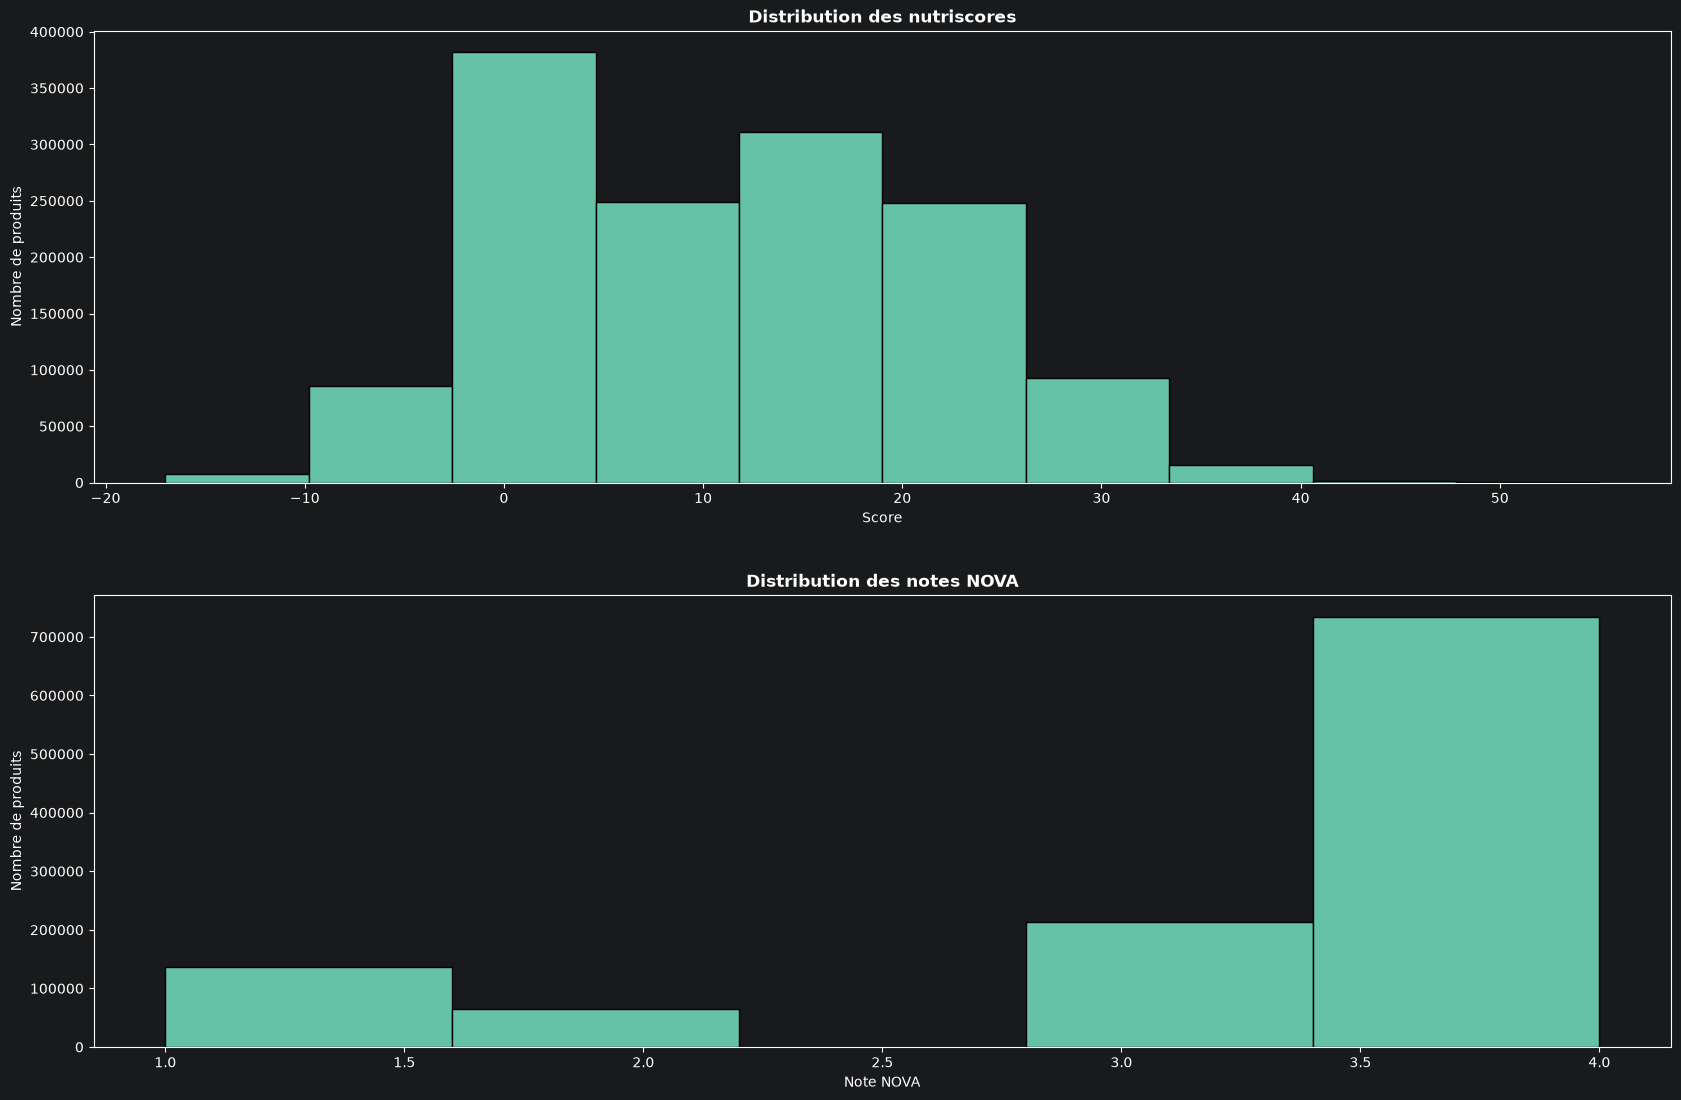

In [12]:
nutriscore_score = df["nutriscore_score"]
nova_group = df["nova_group"]

fig, ax = plt.subplots(2, figsize=(18, 12))

ax1 = ax[0]
ax1.hist(nutriscore_score, color= plt.get_cmap("Set2")(0), edgecolor="black", bins=10)
fig.tight_layout(pad=5)
ax1.set_xlabel(xlabel="Score")
ax1.set_ylabel(ylabel="Nombre de produits")
ax1.set_title("Distribution des nutriscores", fontweight="bold")

ax2 = ax[1]
ax2.hist(nova_group, color= plt.get_cmap("Set2")(0), edgecolor="black", bins=5)
fig.tight_layout(pad=5)
ax2.set_xlabel(xlabel="Note NOVA")
ax2.set_ylabel(ylabel="Nombre de produits")
ax2.set_title("Distribution des notes NOVA", fontweight="bold")

plt.show()